In [1]:
experiment = "vggnet16_benchmark2022_segmented_100_imgs"

import pandas as pd
CSV_PATH = f"../results/{experiment}/combined_results.csv"
df = pd.read_csv(CSV_PATH)

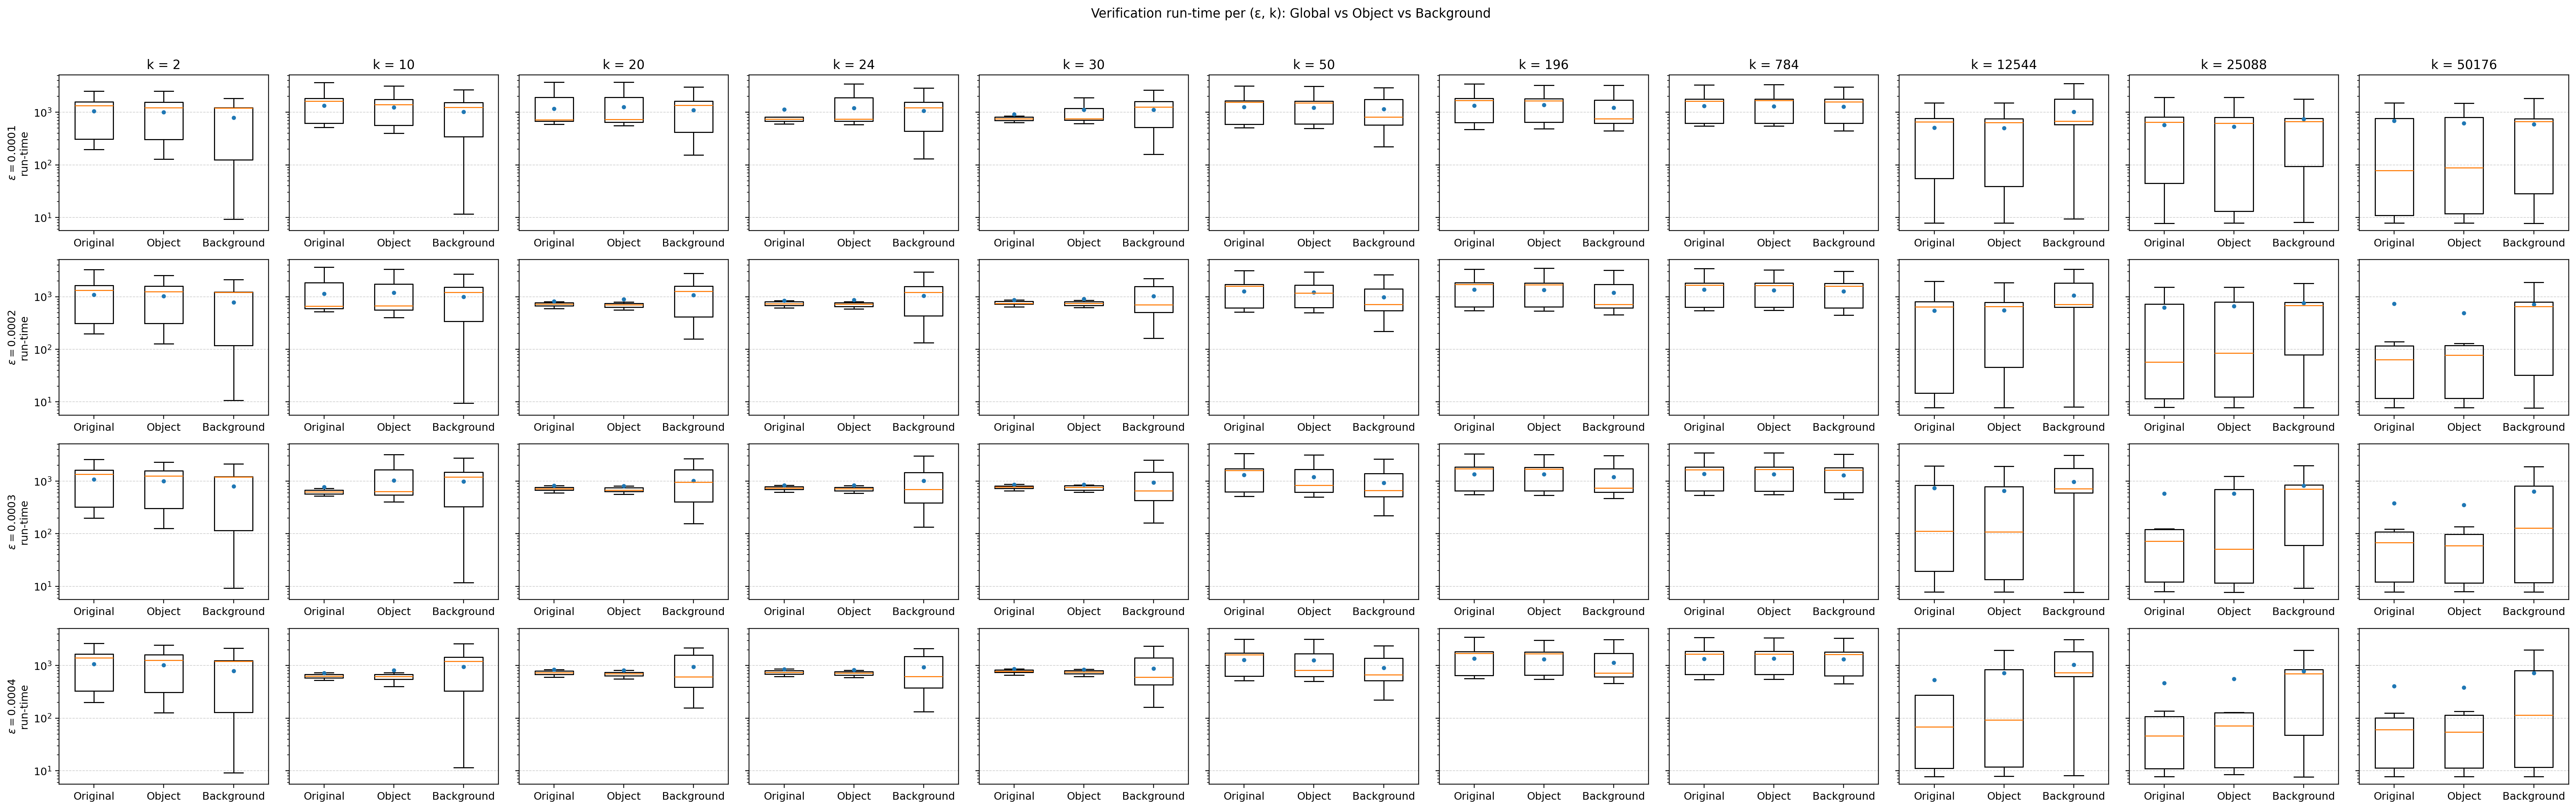

In [9]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Helpers
# ---------------------------
TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)
    keep = pd.Series(True, index=frame.index)

    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def sanitize_numeric(frame: pd.DataFrame):
    out = frame.copy()
    out["eps"] = pd.to_numeric(out["eps"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out[TIME_COL] = pd.to_numeric(out[TIME_COL], errors="coerce")
    out = out.dropna(subset=["eps", "k", TIME_COL]).copy()
    out = out[out[TIME_COL] > 0].copy()
    return out

def grouped_boxplot_one_panel(ax, triplet_data, labels, show_means=True):
    """
    triplet_data: [global_times, object_times, background_times]
    """
    ax.boxplot(triplet_data, tick_labels=labels, showfliers=False, widths=0.55)

    if show_means:
        means = [np.mean(v) if len(v) else np.nan for v in triplet_data]
        ax.plot([1, 2, 3], means, marker="o", linestyle="none", markersize=3)

    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# ---------------------------
# Build subsets (KEEPING YOUR STYLE, but FIXED SEMANTICS)
# ---------------------------

# Global
if "is_global" in df.columns:
    df_global = df[df["is_global"] == True].copy()
else:
    df_global = filter_by_tag_contains(df, include_any=("global",))

# Object verification = fix_nonmask (background fixed)
# (your previous "seg + mask excluding non-mask" was unreliable)
df_object = filter_by_tag_contains(df, include_any=("fixnonmask", "fix_nonmask", "fix_non_mask"))

# Background verification = fix_mask (object fixed)
df_background = filter_by_tag_contains(df, include_any=("fixmask", "fix_mask"))

# Sanitize
df_global = sanitize_numeric(df_global)
df_object = sanitize_numeric(df_object)
df_background = sanitize_numeric(df_background)

# ---------------------------
# Decide which eps and k to plot (12 panels)
# ---------------------------
# Use common eps across all three so panels are comparable
eps_vals = sorted(set(df_global["eps"]) & set(df_object["eps"]) & set(df_background["eps"]))

# Use common k across all three
k_vals = sorted(set(df_global["k"]) & set(df_object["k"]) & set(df_background["k"]))

# If you want EXACTLY 4 eps × 3 k = 12 panels, trim here if needed:
# eps_vals = eps_vals[:4]
# k_vals = k_vals[:3]

# ---------------------------
# Plot grid: rows=eps, cols=k  (=> 4x3 = 12)
# ---------------------------
rows = len(eps_vals)
cols = len(k_vals)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.1, rows*2.6), dpi=220, sharey=True)
axes = np.array(axes).reshape(rows, cols)

xlabels = [
    "Original",
    "Object",
    "Background",
]

for i, eps in enumerate(eps_vals):
    for j, k in enumerate(k_vals):
        ax = axes[i, j]

        g = df_global[(df_global["eps"] == eps) & (df_global["k"] == k)][TIME_COL].values
        o = df_object[(df_object["eps"] == eps) & (df_object["k"] == k)][TIME_COL].values
        b = df_background[(df_background["eps"] == eps) & (df_background["k"] == k)][TIME_COL].values

        grouped_boxplot_one_panel(ax, [g, o, b], xlabels, show_means=True)

        # Titles: keep compact
        if i == 0:
            ax.set_title(f"k = {int(k)}")
        if j == 0:
            ax.set_ylabel(rf"$\epsilon={eps:g}$" + "\nrun-time")

        ax.set_yscale("log")

# overall title
fig.suptitle("Verification run-time per (ε, k): Global vs Object vs Background", y=1.02)

plt.tight_layout()
plt.show()

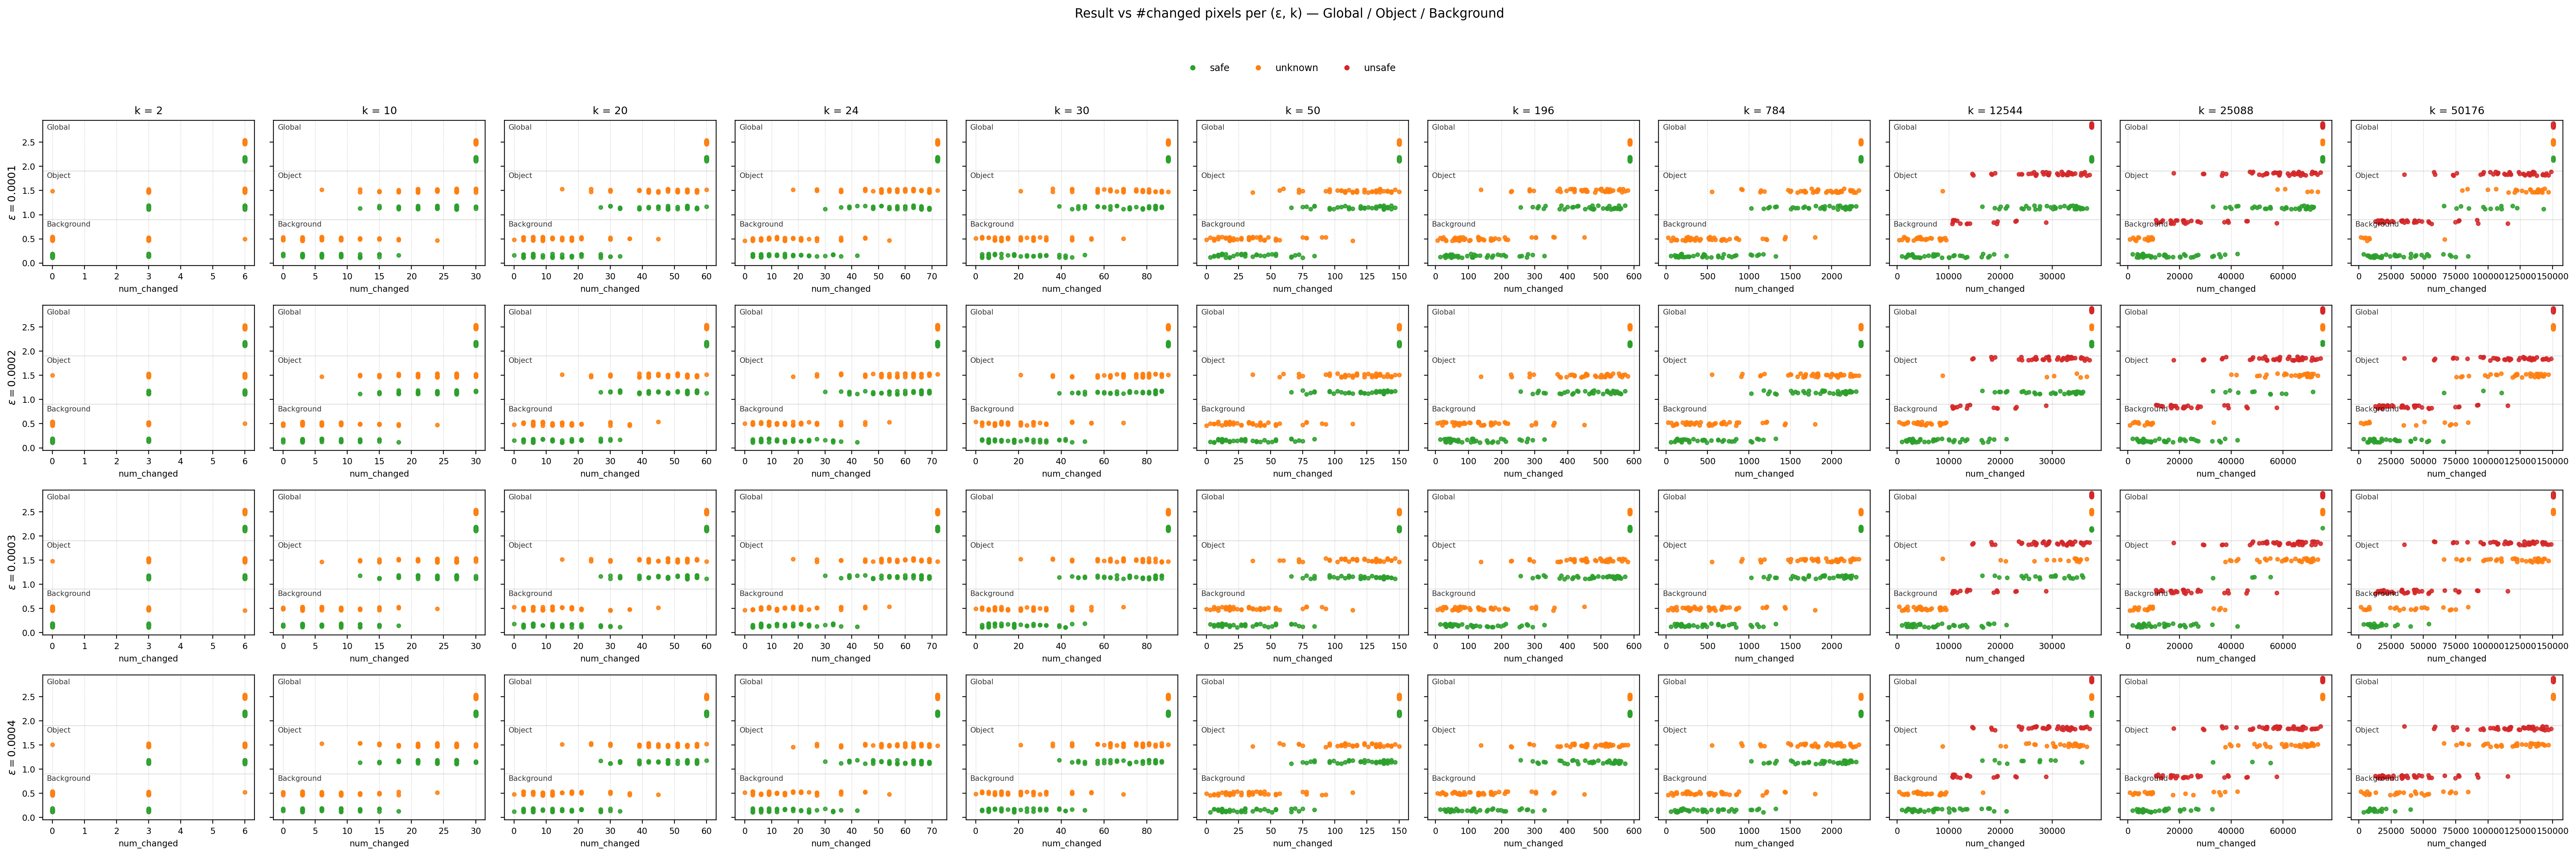

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X_COL = "num_changed"
EPS_COL = "eps"
K_COL = "k"
RES_COL = "result"

# -----------------------------
# 1) Map result -> categories (NEW labels)
# -----------------------------
def map_result(r):
    if pd.isna(r):
        return "other"
    r = str(r).strip().lower()
    if r == "unsat false":
        return "safe"
    if r == "sat true":
        return "unsafe"
    if r == "timeout false":
        return "unknown"
    return "other"

ORDER = ["safe", "unknown", "unsafe", "other"]

COLOR_MAP = {
    "unsafe":  "#d62728",  # red
    "safe":    "#2ca02c",  # green
    "unknown": "#ff7f0e",  # orange
    "other":   "#7f7f7f",  # grey
}

# -----------------------------
# 2) Robust semantic subsets
# -----------------------------
def _text(df, cols=("pattern", "vnnlib", "tag")):
    s = pd.Series("", index=df.index, dtype=str)
    for c in cols:
        if c in df.columns:
            s = s + " " + df[c].astype(str)
    return s.str.lower()

def build_subsets_semantic(df):
    text = _text(df)

    # Global / original
    if "is_global" in df.columns:
        d_global = df[df["is_global"] == True].copy()
    else:
        d_global = df[text.str.contains("global", na=False)].copy()

    # Object verification = fix_nonmask (background fixed)
    d_object = df[text.str.contains(r"\bfixnonmask\b|\bfix_nonmask\b|\bfix_non_mask\b", regex=True, na=False)].copy()

    # Background verification = fix_mask (object fixed)
    d_background = df[text.str.contains(r"\bfixmask\b|\bfix_mask\b", regex=True, na=False)].copy()

    return d_global, d_object, d_background

def sanitize(d):
    d = d.copy()
    d[EPS_COL] = pd.to_numeric(d[EPS_COL], errors="coerce")
    d[K_COL] = pd.to_numeric(d[K_COL], errors="coerce")
    d[X_COL] = pd.to_numeric(d[X_COL], errors="coerce")
    d = d.dropna(subset=[EPS_COL, K_COL, X_COL]).copy()
    d["y_cat"] = d[RES_COL].apply(map_result)
    return d

# -----------------------------
# 3) Make a single (eps,k) cell plot with 3 strips
# -----------------------------
rng = np.random.default_rng(0)

def plot_cell(ax, d_g, d_o, d_b, eps, k, present):
    """
    One axes per (eps, k) cell.
    Three horizontal bands:
      y in [2] Global, [1] Object, [0] Background
    """
    bands = [
        ("Global", d_g, 2.0),
        ("Object", d_o, 1.0),
        ("Background", d_b, 0.0),
    ]

    y_to_num = {c: i for i, c in enumerate(present)}  # 0..(n-1)
    ncat = len(present)

    def band_y(cat_idx, base):
        # spread categories inside [base+0.15, base+0.85]
        if ncat == 1:
            frac = 0.5
        else:
            frac = cat_idx / (ncat - 1)
        return base + 0.15 + 0.70 * frac

    # band separators
    ax.axhline(0.9, color="k", alpha=0.12, linewidth=0.8)
    ax.axhline(1.9, color="k", alpha=0.12, linewidth=0.8)

    for name, dsub, base in bands:
        sub = dsub[(dsub[EPS_COL] == eps) & (dsub[K_COL] == k)].copy()
        if sub.empty:
            continue

        x = sub[X_COL].to_numpy()
        for cat in present:
            mask = (sub["y_cat"] == cat).to_numpy()
            if not mask.any():
                continue

            y0 = band_y(y_to_num[cat], base)
            y = y0 + (rng.random(mask.sum()) - 0.5) * 0.08  # small jitter
            ax.scatter(
                x[mask], y,
                s=12, alpha=0.85,
                color=COLOR_MAP.get(cat, "#7f7f7f")
            )

        # band label
        ax.text(
            0.02, base + 0.80,
            name,
            transform=ax.get_yaxis_transform(),  # x in axes coords, y in data coords
            fontsize=7, alpha=0.8, ha="left", va="center"
        )

    ax.set_ylim(-0.05, 2.95)
    ax.grid(True, axis="x", linestyle="--", linewidth=0.4, alpha=0.6)

# -----------------------------
# 4) Build data
# -----------------------------
d_global, d_object, d_background = build_subsets_semantic(df)
d_global = sanitize(d_global)
d_object = sanitize(d_object)
d_background = sanitize(d_background)

# categories present (consistent across all)
all_cats = set(d_global["y_cat"]) | set(d_object["y_cat"]) | set(d_background["y_cat"])
present = [c for c in ORDER if c in all_cats]
if not present:
    present = ["other"]

# choose eps and k
eps_vals = sorted(set(d_global[EPS_COL]) | set(d_object[EPS_COL]) | set(d_background[EPS_COL]))
k_vals = sorted(set(d_global[K_COL]) | set(d_object[K_COL]) | set(d_background[K_COL]))

# If you want EXACTLY 4 eps × 3 k = 12 panels, set explicitly:
# eps_vals = [0.0001, 0.0002, 0.0003, 0.0004]
# k_vals = [2, 784, 50176]

# -----------------------------
# 5) Grid: rows=eps, cols=k
# -----------------------------
rows = len(eps_vals)
cols = len(k_vals)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.1, rows*2.6), dpi=220, sharex=False, sharey=True)
axes = np.array(axes).reshape(rows, cols)

for i, eps in enumerate(eps_vals):
    for j, k in enumerate(k_vals):
        ax = axes[i, j]
        plot_cell(ax, d_global, d_object, d_background, eps, k, present)

        if i == 0:
            ax.set_title(f"k = {int(k)}", fontsize=10)
        if j == 0:
            ax.set_ylabel(rf"$\epsilon={eps:g}$", fontsize=10)

        ax.set_xlabel("num_changed", fontsize=8)
        ax.tick_params(axis="both", labelsize=8)

        # If num_changed spans huge range, optionally:
        # ax.set_xscale("log")

# One legend (manual, clean)
legend_handles = [
    plt.Line2D([0], [0], marker='o', color='w',
               markerfacecolor=COLOR_MAP[c], markersize=6, label=c)
    for c in present
]
fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=min(6, len(present)),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
    fontsize=9
)

fig.suptitle("Result vs #changed pixels per (ε, k) — Global / Object / Background", y=1.08)
plt.tight_layout()
plt.show()

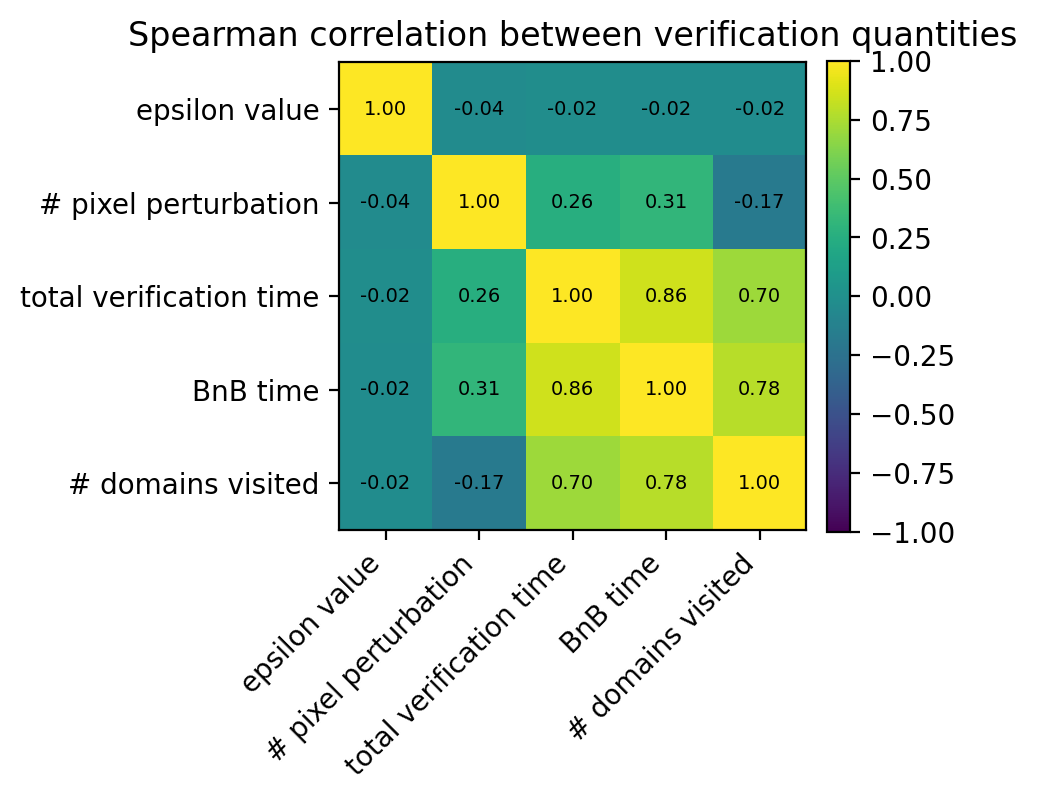

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------
# Select numeric columns
# ---------------------------------------
candidate_cols = [
    "eps",
    "percent_changed",
    "all_time",
    "bab_time",
    "domains_visited",
]

num_cols = [c for c in candidate_cols if c in df.columns]

# Convert to numeric safely
d = df[num_cols].apply(pd.to_numeric, errors="coerce")
d = d.dropna(how="any")

# ---------------------------------------
# Compute correlation (Spearman)
# ---------------------------------------
corr = d.corr(method="spearman")

# ---------------------------------------
# Pretty labels (DISPLAY ONLY)
# ---------------------------------------
LABEL_MAP = {
    "eps": "epsilon value",
    "percent_changed": "# pixel perturbation",
    "all_time": "total verification time",
    "bab_time": "BnB time",
    "domains_visited": "# domains visited",
}

corr = corr.rename(index=LABEL_MAP, columns=LABEL_MAP)

# ---------------------------------------
# Plot correlation heatmap
# ---------------------------------------
fig, ax = plt.subplots(figsize=(4.8, 4.2), dpi=200)

im = ax.imshow(corr, vmin=-1, vmax=1)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)

# Annotate correlation values
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7)

# ✅ title WITHOUT "percentage change only"
ax.set_title("Spearman correlation between verification quantities")

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

Verification cost correlates with perturbation size and search effort, not with ε.

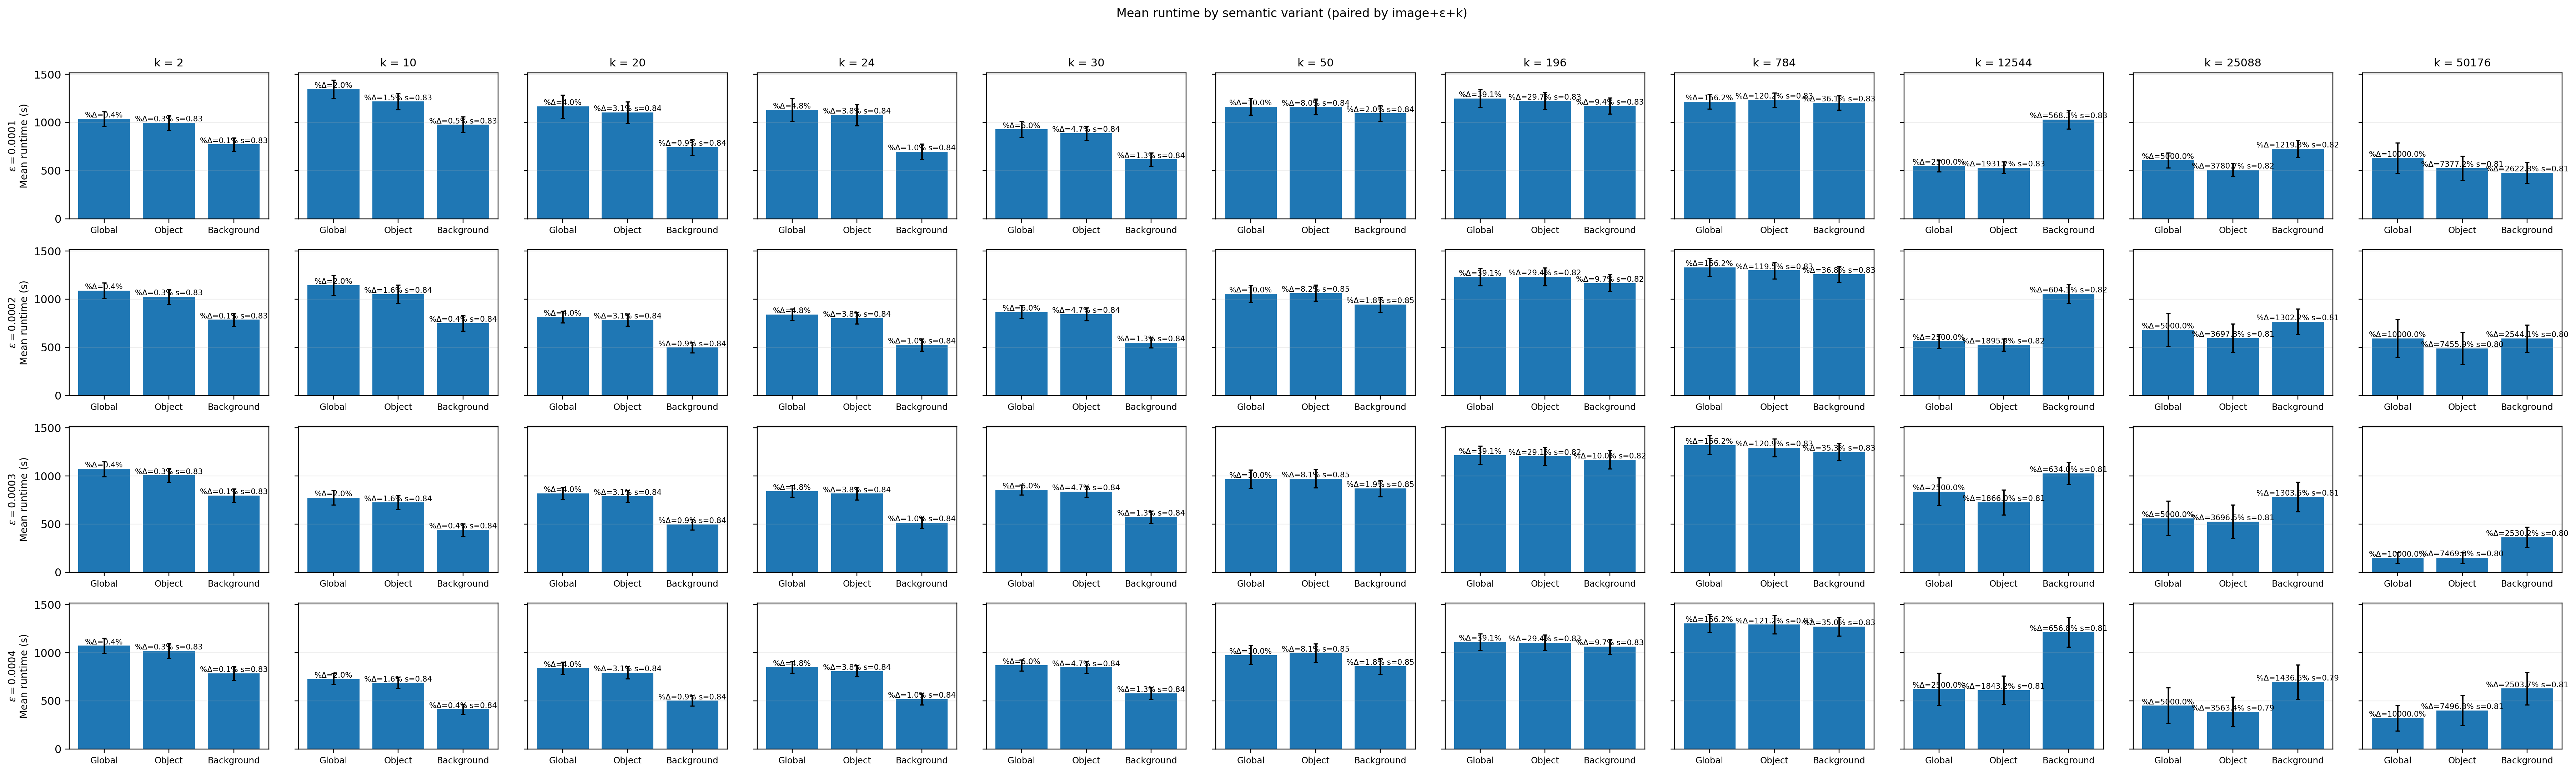

In [14]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"
PAIR_ON_K = True  # must be True for per-(eps,k) panels

# Semantic variants (what you will show)
VARIANTS = [
    "Global verification",
    "Object verification (background fixed)",     # fix_nonmask
    "Background verification (object fixed)",     # fix_mask
]
XTICK_LABELS = ["Global", "Object", "Background"]

# -------------------------
# Helpers
# -------------------------
def _grid(n_panels, max_cols=4):
    cols = min(max_cols, max(1, n_panels))
    rows = int(math.ceil(n_panels / cols))
    return rows, cols

def _sem(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) <= 1:
        return np.nan
    return np.std(x, ddof=1) / np.sqrt(len(x))

def _annotate_bar(ax, x, height, text):
    ax.text(x, height, text, ha="center", va="bottom", fontsize=7)

def classify_variant(row) -> str:
    pat = str(row.get("pattern", "")).lower()
    tag = str(row.get("tag", "")).lower()
    vnn = str(row.get("vnnlib", "")).lower()
    is_global = bool(row.get("is_global", False))
    s = f"{pat} {tag} {vnn}"

    if is_global or " global" in f" {s} " or "_global" in tag:
        return "Global verification"

    # Object verification = fix_nonmask
    if any(k in s for k in ["fixnonmask", "fix_nonmask", "fix_non_mask", "nonmask", "non-mask"]):
        return "Object verification (background fixed)"

    # Background verification = fix_mask
    if any(k in s for k in ["fixmask", "fix_mask", "fix-mask"]):
        return "Background verification (object fixed)"

    return None

# -------------------------
# Numeric cleaning
# -------------------------
df = df.copy()
for col in ["eps", "k", TIME_COL, "percent_changed", "score"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Build semantic variant
df["variant"] = df.apply(classify_variant, axis=1)
df = df[df["variant"].isin(VARIANTS)].copy()

# Optional: keep only segment_index==0 for non-global segmented rows
if "segment_index" in df.columns:
    df = df[(df["variant"] == "Global verification") | (df["segment_index"] == 0)].copy()

# -------------------------
# Pairing key (must include k)
# -------------------------
index_cols = ["image", "eps"] + (["k"] if (PAIR_ON_K and "k" in df.columns) else [])
if "k" not in index_cols:
    raise ValueError("To make per-(eps,k) plots, PAIR_ON_K must be True and column 'k' must exist.")

# -------------------------
# Wide tables: runtime + percent_changed + score
# -------------------------
time_wide = df.pivot_table(
    index=index_cols,
    columns="variant",
    values=TIME_COL,
    aggfunc="mean"
).reset_index()

pct_wide = None
if "percent_changed" in df.columns:
    pct_wide = df.pivot_table(
        index=index_cols,
        columns="variant",
        values="percent_changed",
        aggfunc="mean"
    ).reset_index()
    for v in VARIANTS:
        if v in pct_wide.columns:
            pct_wide = pct_wide.rename(columns={v: f"{v}_pct"})

score_wide = None
if "score" in df.columns:
    score_wide = df.pivot_table(
        index=index_cols,
        columns="variant",
        values="score",
        aggfunc="mean"
    ).reset_index()
    for v in VARIANTS:
        if v in score_wide.columns:
            score_wide = score_wide.rename(columns={v: f"{v}_score"})

all3 = time_wide
if pct_wide is not None:
    all3 = all3.merge(pct_wide, on=index_cols, how="left")
if score_wide is not None:
    all3 = all3.merge(score_wide, on=index_cols, how="left")

# Fully paired only
need_cols = [v for v in VARIANTS if v in all3.columns]
plot_df = all3.dropna(subset=need_cols).copy()

# -------------------------
# Choose eps and k values to plot
# -------------------------
eps_values = sorted(plot_df["eps"].dropna().unique())
k_values = sorted(plot_df["k"].dropna().unique())

# If you want EXACTLY 12 plots, set these explicitly:
# eps_values = [0.0001, 0.0002, 0.0003, 0.0004]
# k_values = [2, 784, 50176]

# -------------------------
# Plot grid: rows=eps, cols=k
# -------------------------
rows = len(eps_values)
cols = len(k_values)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.0, rows*2.4), dpi=220, sharey=True)
axes = np.array(axes).reshape(rows, cols)

xpos = np.arange(len(VARIANTS))

for i, eps in enumerate(eps_values):
    for j, k in enumerate(k_values):
        ax = axes[i, j]
        sub = plot_df[(plot_df["eps"] == eps) & (plot_df["k"] == k)].copy()

        if sub.empty:
            ax.axis("off")
            continue

        means = [sub[v].mean() if v in sub.columns else np.nan for v in VARIANTS]
        sems  = [_sem(sub[v].values) if v in sub.columns else np.nan for v in VARIANTS]

        ax.bar(xpos, means, yerr=sems, capsize=2)
        ax.set_xticks(xpos)
        ax.set_xticklabels(XTICK_LABELS, fontsize=8)

        # Titles: clean, no n=
        if i == 0:
            ax.set_title(f"k = {int(k)}", fontsize=10)
        if j == 0:
            ax.set_ylabel(rf"$\epsilon = {eps:g}$" + "\nMean runtime (s)", fontsize=9)

        ax.grid(True, axis="y", alpha=0.2)

        # annotations: %Δ + score
        for t, v in enumerate(VARIANTS):
            pct_col = f"{v}_pct"
            sc_col  = f"{v}_score"

            pct_mean = sub[pct_col].mean() if pct_col in sub.columns else np.nan
            sc_mean  = sub[sc_col].mean() if sc_col in sub.columns else np.nan

            label_parts = []
            if not np.isnan(pct_mean):
                label_parts.append(f"%Δ={pct_mean*100:.1f}%")
            if v != "Global verification" and not np.isnan(sc_mean):
                label_parts.append(f"s={sc_mean:.2f}")

            if label_parts and not np.isnan(means[t]):
                _annotate_bar(ax, t, means[t], " ".join(label_parts))

# overall title
pair_note = "image+ε+k"
fig.suptitle(f"Mean runtime by semantic variant (paired by {pair_note})", y=1.02, fontsize=11)

plt.tight_layout()
plt.show()

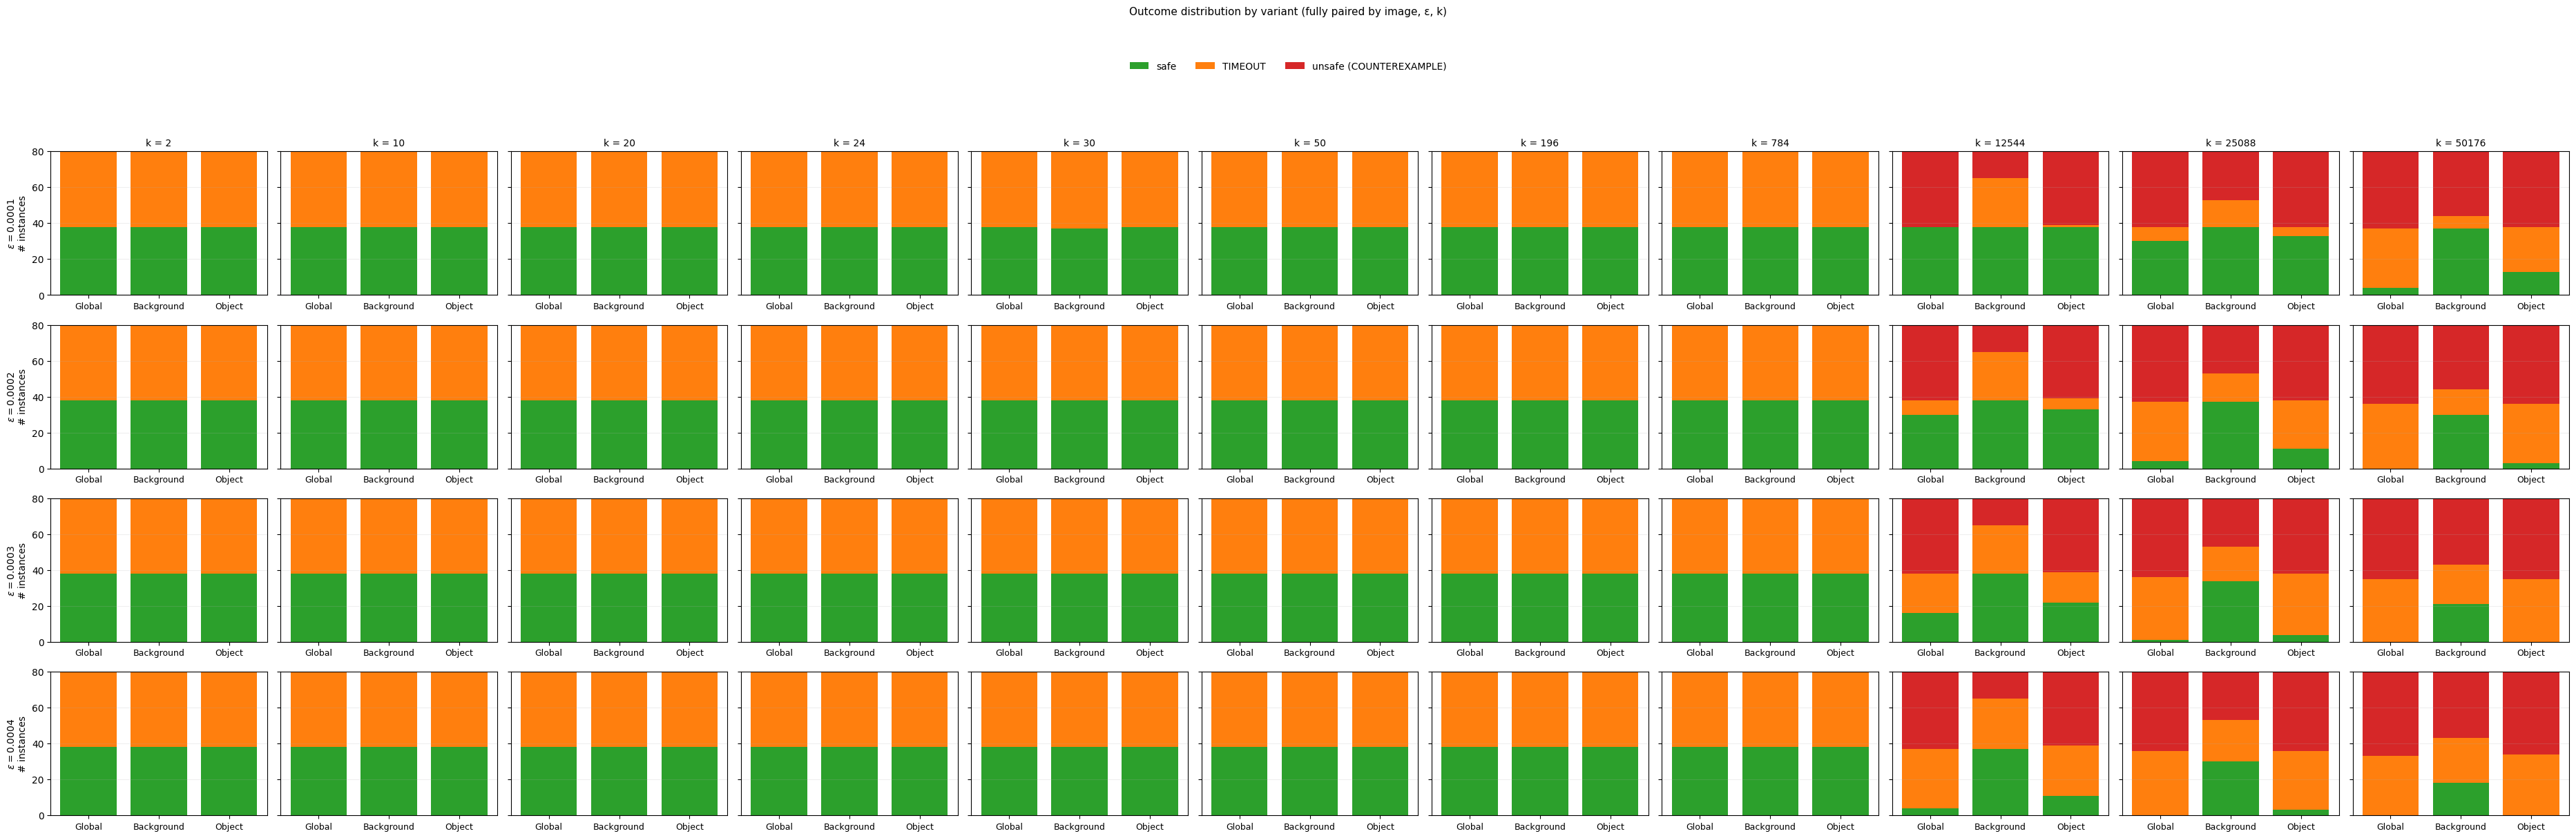

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
PAIR_COLS = ["image", "eps", "k"]

VARIANTS = ["Global", "Background", "Object"]
XTICK_LABELS = ["Global", "Background", "Object"]

# RESULT LABEL NORMALIZATION
RESULT_RENAME = {
    "unsat False": "safe",
    "timeout False": "TIMEOUT",
    "sat True": "unsafe (COUNTEREXAMPLE)",
}

RESULT_COLORS = {
    "unsafe (COUNTEREXAMPLE)": "#d62728",  # red
    "safe": "#2ca02c",                     # green
    "TIMEOUT": "#ff7f0e",                  # orange
}

RESULT_ORDER = ["safe", "TIMEOUT", "unsafe (COUNTEREXAMPLE)"]

# -----------------------------
# LOAD / CLEAN
# -----------------------------
df = df.copy()
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["result"] = df["result"].astype(str)

# -----------------------------
# VARIANT CLASSIFIER (correct semantics)
# FixMask    -> Background
# FixNonMask -> Object
# -----------------------------
def classify_variant(row):
    pat = str(row.get("pattern", "")).lower()
    tag = str(row.get("tag", "")).lower()
    vnn = str(row.get("vnnlib", "")).lower()
    is_global = bool(row.get("is_global", False))

    if is_global or pat == "global" or "_global" in tag or "_global" in vnn:
        return "Global"

    s = " ".join([pat, tag, vnn])

    # prioritize fix_* keys
    if any(k in s for k in ["fix_mask", "fix-mask", "fixmask"]):
        return "Background"
    if any(k in s for k in ["fix_nonmask", "fix-nonmask", "fixnonmask", "fix_non_mask"]):
        return "Object"

    # fallback keys
    if any(k in s for k in ["background", "bg", "nonmask", "non-mask"]):
        return "Background"
    # NOTE: plain "mask" can collide with "nonmask"; keep it last
    if any(k in s for k in [" object", " obj", "foreground"]):
        return "Object"

    return None

df["variant"] = df.apply(classify_variant, axis=1)
df = df[df["variant"].isin(VARIANTS)].copy()

# Keep only seg0 for non-global
if "segment_index" in df.columns:
    df = df[(df["variant"] == "Global") | (df["segment_index"] == 0)].copy()

# Clean results
df = df[df["result"].isin(RESULT_RENAME)].copy()
df["result_clean"] = df["result"].map(RESULT_RENAME)

# -----------------------------
# PAIRED WIDE TABLE (fully paired)
# -----------------------------
res_all3 = df.pivot_table(
    index=PAIR_COLS,
    columns="variant",
    values="result_clean",
    aggfunc="first"
).reset_index()

res_all3 = res_all3.dropna(subset=VARIANTS).copy()

# -----------------------------
# MANY PLOTS: grid per (eps, k)
# rows = eps, cols = k
# -----------------------------
eps_values = sorted(res_all3["eps"].dropna().unique())
k_values = sorted(res_all3["k"].dropna().unique())

# If you want exactly 12 panels, set these explicitly:
# eps_values = [0.0001, 0.0002, 0.0003, 0.0004]
# k_values = [2, 784, 50176]

rows = len(eps_values)
cols = len(k_values)

fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 3.4, rows * 2.8),
    squeeze=False,
    sharey=True
)

x = np.arange(len(VARIANTS))

for i, eps in enumerate(eps_values):
    for j, k in enumerate(k_values):
        ax = axes[i][j]
        sub = res_all3[(res_all3["eps"] == eps) & (res_all3["k"] == k)]

        if sub.empty:
            ax.axis("off")
            continue

        bottom = np.zeros(len(VARIANTS), dtype=float)

        for lab in RESULT_ORDER:
            vals = np.array([(sub[v] == lab).sum() for v in VARIANTS], dtype=float)
            ax.bar(
                x, vals,
                bottom=bottom,
                color=RESULT_COLORS[lab],
                label=lab if (i == 0 and j == 0) else None
            )
            bottom += vals

        ax.set_xticks(x)
        ax.set_xticklabels(XTICK_LABELS, fontsize=9)
        ax.grid(True, axis="y", alpha=0.2)

        # clean titles (no n=..., no images=...)
        if i == 0:
            ax.set_title(f"k = {int(k)}", fontsize=10)
        if j == 0:
            ax.set_ylabel(rf"$\epsilon = {eps:g}$" + "\n# instances", fontsize=10)

# Legend once
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02)
)

fig.suptitle(
    "Outcome distribution by variant (fully paired by image, ε, k)",
    y=1.08,
    fontsize=11
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

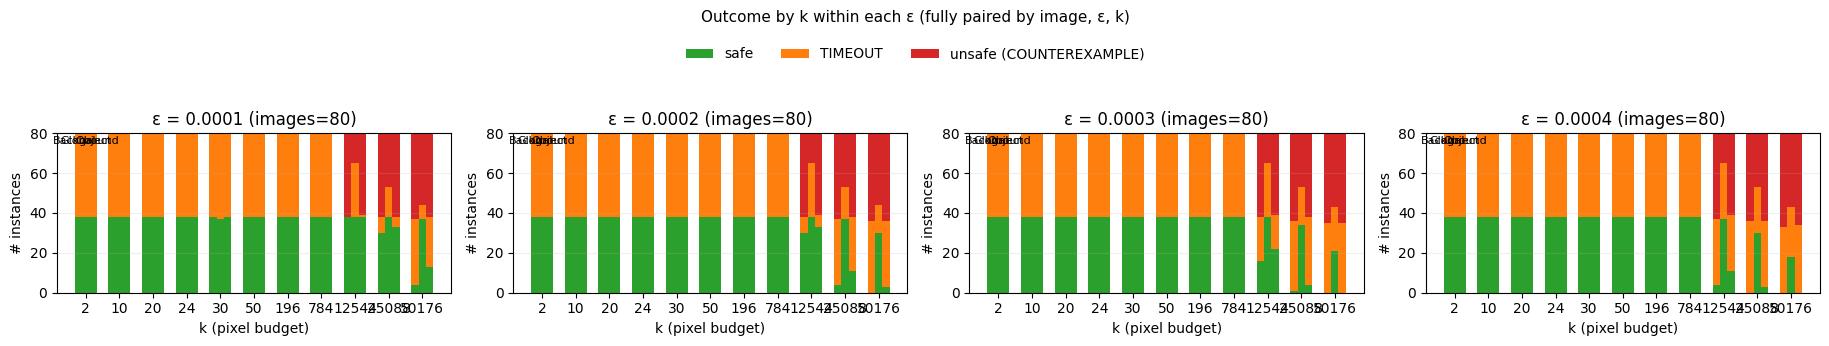

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Assumes you already have:
# res_all3 : wide table with columns ["image","eps","k","Global","Background","Object"]
# VARIANTS = ["Global","Background","Object"]
# RESULT_ORDER = ["safe","TIMEOUT","unsafe (COUNTEREXAMPLE)"]
# RESULT_COLORS = {...}

def _eps_grid(eps_values, max_cols=4):
    n = len(eps_values)
    cols = min(max_cols, max(1, n))
    rows = math.ceil(n / cols)
    return rows, cols

eps_values = sorted(res_all3["eps"].dropna().unique())
k_values_all = sorted(res_all3["k"].dropna().unique())

max_cols = 4
rows, cols = _eps_grid(eps_values, max_cols=max_cols)

# width tuning
bar_w = 0.22            # width of each variant bar inside a k-group
gap_k = 0.35            # extra spacing between k-groups

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4.6, rows * 3.1), squeeze=False)

for idx, eps in enumerate(eps_values):
    r, c = divmod(idx, cols)
    ax = axes[r][c]
    sub_eps = res_all3[res_all3["eps"] == eps].copy()

    # only k values present for this eps
    k_values = sorted(sub_eps["k"].dropna().unique())
    if len(k_values) == 0:
        ax.axis("off")
        continue

    # x positions: one group per k, with 3 bars (Global/Background/Object) per group
    group_x = np.arange(len(k_values)) * (3 * bar_w + gap_k)
    offsets = np.array([-bar_w, 0.0, bar_w])  # for 3 variants

    # Plot stacked outcomes for each variant bar
    for vi, variant in enumerate(["Global", "Background", "Object"]):
        x = group_x + offsets[vi]
        bottom = np.zeros(len(k_values), dtype=float)

        for lab in RESULT_ORDER:
            vals = []
            for kk in k_values:
                sub = sub_eps[sub_eps["k"] == kk]
                vals.append(float((sub[variant] == lab).sum()))
            vals = np.array(vals, dtype=float)

            ax.bar(
                x, vals,
                width=bar_w,
                bottom=bottom,
                color=RESULT_COLORS[lab],
                label=lab if (idx == 0 and vi == 0) else None  # legend once
            )
            bottom += vals

    # x tick per k-group
    ax.set_xticks(group_x)
    ax.set_xticklabels([str(int(k)) if float(k).is_integer() else str(k) for k in k_values], rotation=0)
    ax.set_xlabel("pixel change")

    n_images = sub_eps["image"].nunique()
    ax.set_title(f"ε = {eps:g} (images={n_images})")
    ax.set_ylabel("# instances")
    ax.grid(True, axis="y", alpha=0.2)

    # small annotation for which bar is which
    # Put variant labels near the first k-group
    if len(k_values) > 0:
        y0 = ax.get_ylim()[1] * 0.98
        for vi, name in enumerate(["Global","Background","Object"]):
            ax.text(group_x[0] + offsets[vi], y0, name, ha="center", va="top", fontsize=8)

# Hide unused axes
for j in range(len(eps_values), rows * cols):
    r, c = divmod(j, cols)
    axes[r][c].axis("off")

# Legend
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False, bbox_to_anchor=(0.5, 1.02))

fig.suptitle("Outcome by k within each ε (fully paired by image, ε, k)", y=1.10, fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()